### Imports and global parameters

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import heapq
import math

from scipy.stats import t as student_t
from IPython.display import display

In [11]:
# Simulation horizon: one year
T_END = 365.0

# Lognormal parameters from the assignment
SIGMA2_LOG = math.log(2.0)
SIGMA_LOG = math.sqrt(SIGMA2_LOG)

MU_LOG = {
    1: math.log(4.0 * math.sqrt(2.0)),  # Type 1: mean and sd 8 days, for ward A
    2: math.log(6.0 * math.sqrt(2.0)),  # Type 2: mean and sd 12 days, for ward B
    3: math.log(5.0 * math.sqrt(2.0)),  # Type 3: mean and sd 10 days, for ward C
}

# Means used for the exponential LOS sensitivity analysis
MEAN_LOS = {
    1: 8.0, # Type 1: mean and sd 8 days, for ward A
    2: 12.0, # Type 2: mean and sd 12 days, for ward B
    3: 10.0,  # Type 3: mean and sd 10 days, for ward C
}

# Reproducibility
BASE_SEED = 1


def spawn_child_seeds(seed, n_children):
    """
    Derive reproducible child seeds from one base seed.

    Use seed=BASE_SEED for top-level experiments. When several independent
    streams are needed, use child seeds instead of resetting every stream to 1.
    Passing seed=None deliberately requests non-reproducible child seeds.
    """
    seed_sequence = np.random.SeedSequence(seed)

    return [
        int(child.generate_state(1, dtype=np.uint32)[0])
        for child in seed_sequence.spawn(n_children)
    ]

### Seeding strategy

All stochastic code uses local NumPy generators rather than the global random state. The visible base seed is `BASE_SEED = 1`. A single simulation uses that seed directly by default. Routines that need several streams derive child seeds from the base seed, so replications are reproducible but not identical. Allocation comparisons reuse the same replication seed sequence across candidate allocations where sensible, reducing unrelated Monte Carlo noise in the ranking.

### Arrival functions

In [12]:
def lambda1(t):
    """
    Arrival rate for type 1 regular epidemic patients.
    The rate is measured in patients per day.
    """
    t = np.asarray(t)
    return np.maximum(0.0, -(1.0 / 3650.0) * t**2 + 0.1 * t)


def lambda2(t):
    """
    Arrival rate for type 2 intensive-care epidemic patients.
    """
    return lambda1(t) / 5.0


def lambda3(t):
    """
    Arrival rate for type 3 other patients.
    """
    t = np.asarray(t)
    return 6.0 + 0.0 * t

### Plot of arrival rates

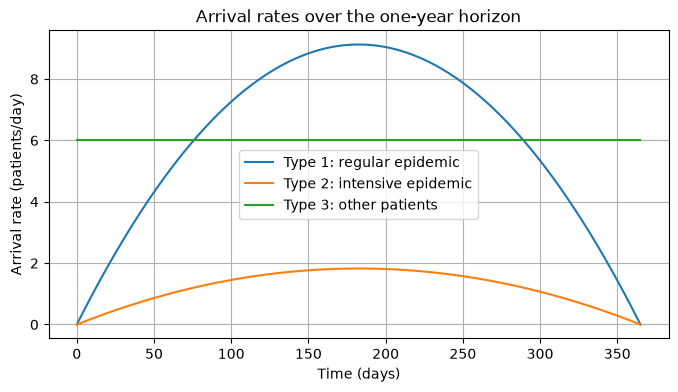

In [13]:
t_grid = np.linspace(0, T_END, 500)

plt.figure(figsize=(8, 4))
plt.plot(t_grid, lambda1(t_grid), label="Type 1: regular epidemic")
plt.plot(t_grid, lambda2(t_grid), label="Type 2: intensive epidemic")
plt.plot(t_grid, lambda3(t_grid), label="Type 3: other patients")
plt.xlabel("Time (days)")
plt.ylabel("Arrival rate (patients/day)")
plt.title("Arrival rates over the one-year horizon")
plt.legend()
plt.grid(True)
plt.show()

### Daily poisson arrival generation

The true arrival rate λi(t) changes continuously over time. To keep things simple, we approximate it as constant within each day by evaluating it at the midpoint of the day:

d+0.5.

So for day d, we use

λi(d+0.5)

as the average arrival rate for that whole day.

Since the rate is measured in patients per day, the number of arrivals during that day is simulated as

Ni,d∼Poisson(λi(d+0.5)).

In [14]:
def generate_daily_poisson_arrivals(rate_func, horizon, rng):
    """
    Generate arrival times using a simple daily Poisson approximation.

    For each day d:
        N_d ~ Poisson(lambda(d + 0.5) * day_length)

    Conditional on N_d, the arrivals are placed uniformly in the day.
    """
    arrivals = []
    n_days = int(np.ceil(horizon))

    for d in range(n_days):
        day_start = float(d)
        day_end = min(float(d + 1), horizon)
        day_length = day_end - day_start

        midpoint = day_start + 0.5 * day_length
        rate = float(rate_func(midpoint))

        mean_arrivals = rate * day_length
        n_arrivals = rng.poisson(mean_arrivals)

        if n_arrivals > 0:
            times = rng.uniform(day_start, day_end, size=n_arrivals)
            arrivals.extend(times)

    return np.sort(np.array(arrivals))

### Expected arrivals given approximation

In [15]:
def expected_arrivals_daily_approx(horizon=T_END):
    """
    Expected number of arrivals under the same daily approximation
    used in the simulation. Used for sanity checks and sensitivity analyses.
    """
    n_days = int(np.ceil(horizon))

    exp1 = 0.0
    exp2 = 0.0
    exp3 = 0.0

    for d in range(n_days):
        day_start = float(d)
        day_end = min(float(d + 1), horizon)
        day_length = day_end - day_start
        midpoint = day_start + 0.5 * day_length

        exp1 += float(lambda1(midpoint)) * day_length
        exp2 += float(lambda2(midpoint)) * day_length
        exp3 += float(lambda3(midpoint)) * day_length

    return {
        "type1": exp1,
        "type2": exp2,
        "type3": exp3,
    }


expected_arrivals_daily_approx()

{'type1': 2220.425000000001, 'type2': 444.0850000000003, 'type3': 2190.0}

### Length of stay sampling

In [16]:
def sample_los(patient_type, los_model, rng):
    """
    Sample length of stay for a patient type.

    los_model:
        "lognormal"   -> main model
        "exponential" -> sensitivity model
    """
    if los_model == "lognormal":
        return rng.lognormal(
            mean=MU_LOG[patient_type],
            sigma=SIGMA_LOG
        )

    if los_model == "exponential":
        return rng.exponential(
            scale=MEAN_LOS[patient_type]
        )

    raise ValueError("los_model must be 'lognormal' or 'exponential'")

### Simulate one year for one bed allocation

In [17]:
def simulate_one_year(beds, los_model="lognormal", seed=BASE_SEED):
    """
    Simulate one year of patient flow for a fixed bed allocation.

    beds = (bA, bB, bC)

    Ward rules:
        Type 1: Ward A if possible, otherwise relocated.
        Type 2: Ward B if possible, otherwise Ward A if possible, otherwise relocated.
        Type 3: Ward C if possible, otherwise relocated.
    """

    bA, bB, bC = beds
    rng = np.random.default_rng(seed)

    # Generate arrival times
    arrivals1 = generate_daily_poisson_arrivals(lambda1, T_END, rng)
    arrivals2 = generate_daily_poisson_arrivals(lambda2, T_END, rng)
    arrivals3 = generate_daily_poisson_arrivals(lambda3, T_END, rng)

    # Event list.
    # Each event is represented as:
    # (event_time, priority, counter, event_type, patient_type, ward)
    #
    # priority = 0 for departures
    # priority = 1 for arrivals
    #
    # If an arrival and departure happen at exactly the same time,
    # the departure is processed first.
    event_list = []
    counter = 0

    for time in arrivals1:
        heapq.heappush(event_list, (float(time), 1, counter, "arrival", 1, None))
        counter += 1

    for time in arrivals2:
        heapq.heappush(event_list, (float(time), 1, counter, "arrival", 2, None))
        counter += 1

    for time in arrivals3:
        heapq.heappush(event_list, (float(time), 1, counter, "arrival", 3, None))
        counter += 1

    # State variables: occupied beds
    NA = 0
    NB = 0
    NC = 0

    # Statistical accumulators for time-average utilization
    area_A = 0.0
    area_B = 0.0
    area_C = 0.0
    last_time = 0.0

    # Counters
    arrivals = {1: 0, 2: 0, 3: 0}
    relocated = {1: 0, 2: 0, 3: 0}

    # Full-on-arrival counters
    # Type 1: Ward A full
    # Type 2: Ward B full
    # Type 3: Ward C full
    full_on_arrival = {1: 0, 2: 0, 3: 0}

    # Extra statistic for type 2
    overflow2_to_A = 0

    while event_list:
        event_time, priority, _, event_type, patient_type, ward = heapq.heappop(event_list)

        if event_time > T_END:
            break

        # Update time-integrated occupancy since previous event
        dt = event_time - last_time
        area_A += NA * dt
        area_B += NB * dt
        area_C += NC * dt
        last_time = event_time

        if event_type == "departure":

            if ward == "A":
                NA -= 1
            elif ward == "B":
                NB -= 1
            elif ward == "C":
                NC -= 1
            else:
                raise ValueError("Unknown ward in departure event")

        elif event_type == "arrival":

            arrivals[patient_type] += 1
            admitted_ward = None

            # Type 1: regular epidemic patients
            if patient_type == 1:
                if NA < bA:
                    NA += 1
                    admitted_ward = "A"
                else:
                    full_on_arrival[1] += 1
                    relocated[1] += 1

            # Type 2: intensive-care epidemic patients
            elif patient_type == 2:
                if NB < bB:
                    NB += 1
                    admitted_ward = "B"
                else:
                    # Ward B is full, so this is counted as full-on-arrival for Ward B
                    full_on_arrival[2] += 1

                    # Try overflow to Ward A
                    if NA < bA:
                        NA += 1
                        admitted_ward = "A"
                        overflow2_to_A += 1
                    else:
                        relocated[2] += 1

            # Type 3: other patients
            elif patient_type == 3:
                if NC < bC:
                    NC += 1
                    admitted_ward = "C"
                else:
                    full_on_arrival[3] += 1
                    relocated[3] += 1

            else:
                raise ValueError("Unknown patient type")

            # Schedule departure if patient was admitted
            if admitted_ward is not None:
                los = sample_los(patient_type, los_model, rng)
                departure_time = event_time + los

                if departure_time <= T_END:
                    heapq.heappush(
                        event_list,
                        (float(departure_time), 0, counter, "departure", patient_type, admitted_ward)
                    )
                    counter += 1

        else:
            raise ValueError("Unknown event type")

    # Add utilization contribution from last event to end of year
    if last_time < T_END:
        dt = T_END - last_time
        area_A += NA * dt
        area_B += NB * dt
        area_C += NC * dt

    def safe_divide(x, y):
        return np.nan if y == 0 else x / y

    result = {
        "bA": bA,
        "bB": bB,
        "bC": bC,
        "los_model": los_model,

        # Arrivals
        "arrivals1": arrivals[1],
        "arrivals2": arrivals[2],
        "arrivals3": arrivals[3],

        # Relocations
        "relocated1": relocated[1],
        "relocated2": relocated[2],
        "relocated3": relocated[3],
        "relocated_total": relocated[1] + relocated[2] + relocated[3],

        # Full on arrival
        "full_arrival1": full_on_arrival[1],
        "full_arrival2_B_full": full_on_arrival[2],
        "full_arrival3": full_on_arrival[3],

        # Overflow
        "overflow2_to_A": overflow2_to_A,

        # Probabilities
        "p_full1": safe_divide(full_on_arrival[1], arrivals[1]),
        "p_full2_B_full": safe_divide(full_on_arrival[2], arrivals[2]),
        "p_full3": safe_divide(full_on_arrival[3], arrivals[3]),

        "p_relocated1": safe_divide(relocated[1], arrivals[1]),
        "p_relocated2": safe_divide(relocated[2], arrivals[2]),
        "p_relocated3": safe_divide(relocated[3], arrivals[3]),

        # Utilization
        "util_A": safe_divide(area_A, T_END * bA),
        "util_B": safe_divide(area_B, T_END * bB),
        "util_C": safe_divide(area_C, T_END * bC),

        # End occupancies, mostly useful for checking/debugging
        "end_NA": NA,
        "end_NB": NB,
        "end_NC": NC,
    }

    return result

| Component | Code |
|---|---|
| Simulation clock | `event_time`, `last_time` |
| State variables | `NA`, `NB`, `NC` |
| Event list | `event_list` |
| Statistical accumulators | `area_A`, `area_B`, `area_C`, arrival and relocation counters |

### Replications and CIs

In [ ]:
def run_replications(beds, n_rep=100, los_model="lognormal", seed=BASE_SEED):
    """
    Run independent replications for a fixed bed allocation.
    """
    seeds = spawn_child_seeds(seed, n_rep)

    rows = []

    for s in seeds:
        rows.append(
            simulate_one_year(
                beds=beds,
                los_model=los_model,
                seed=int(s)
            )
        )

    return pd.DataFrame(rows)

In [19]:
def ci_mean(x, confidence=0.95):
    """
    Compute mean, standard deviation, standard error,
    and a t-based confidence interval.
    """
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    mean = x.mean()

    if n <= 1:
        return pd.Series({
            "mean": mean,
            "sd": np.nan,
            "se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
        })

    sd = x.std(ddof=1)
    se = sd / np.sqrt(n)
    q = student_t.ppf((1 + confidence) / 2, df=n - 1)

    return pd.Series({
        "mean": mean,
        "sd": sd,
        "se": se,
        "ci_low": mean - q * se,
        "ci_high": mean + q * se,
    })

In [20]:
def summarise_replications(rep_df):
    """
    General summary of the most important simulation outputs.
    """
    metrics = [
        "arrivals1", "arrivals2", "arrivals3",
        "relocated1", "relocated2", "relocated3", "relocated_total",
        "p_full1", "p_full2_B_full", "p_full3",
        "p_relocated1", "p_relocated2", "p_relocated3",
        "overflow2_to_A",
        "util_A", "util_B", "util_C",
    ]

    rows = []

    for metric in metrics:
        s = ci_mean(rep_df[metric])
        s["metric"] = metric
        rows.append(s)

    return pd.DataFrame(rows)[["metric", "mean", "sd", "se", "ci_low", "ci_high"]]

### Summary tables

In [21]:
def patient_performance_table(rep_df):
    """
    Summarize performance by patient type.
    """
    rows = []

    rows.append({
        "type": 1,
        "patient_group": "Regular epidemic",
        "admission_rule": "Ward A, otherwise relocated",
        "mean_arrivals": rep_df["arrivals1"].mean(),
        "mean_relocated": rep_df["relocated1"].mean(),
        "p_full_on_arrival": rep_df["p_full1"].mean(),
        "p_relocated": rep_df["p_relocated1"].mean(),
    })

    rows.append({
        "type": 2,
        "patient_group": "Intensive epidemic",
        "admission_rule": "Ward B, overflow to A, otherwise relocated",
        "mean_arrivals": rep_df["arrivals2"].mean(),
        "mean_relocated": rep_df["relocated2"].mean(),
        "p_B_full_on_arrival": rep_df["p_full2_B_full"].mean(),
        "p_relocated": rep_df["p_relocated2"].mean(),
        "mean_overflow_to_A": rep_df["overflow2_to_A"].mean(),
    })

    rows.append({
        "type": 3,
        "patient_group": "Other",
        "admission_rule": "Ward C, otherwise relocated",
        "mean_arrivals": rep_df["arrivals3"].mean(),
        "mean_relocated": rep_df["relocated3"].mean(),
        "p_full_on_arrival": rep_df["p_full3"].mean(),
        "p_relocated": rep_df["p_relocated3"].mean(),
    })

    return pd.DataFrame(rows)

In [22]:
def relocation_summary_table(rep_df):
    """
    Relocations by patient type and total, with confidence intervals.
    """
    rows = []

    for label, col in [
        ("Type 1", "relocated1"),
        ("Type 2", "relocated2"),
        ("Type 3", "relocated3"),
        ("Total", "relocated_total"),
    ]:
        ci = ci_mean(rep_df[col])

        rows.append({
            "group": label,
            "mean_relocated": ci["mean"],
            "ci_low": ci["ci_low"],
            "ci_high": ci["ci_high"],
        })

    return pd.DataFrame(rows)

In [23]:
def ward_utilisation_table(rep_df, beds):
    """
    Ward utilization with confidence intervals.
    """
    bA, bB, bC = beds

    rows = []

    for ward, beds_in_ward, col in [
        ("A", bA, "util_A"),
        ("B", bB, "util_B"),
        ("C", bC, "util_C"),
    ]:
        ci = ci_mean(rep_df[col])

        rows.append({
            "ward": ward,
            "beds": beds_in_ward,
            "mean_utilisation": ci["mean"],
            "ci_low": ci["ci_low"],
            "ci_high": ci["ci_high"],
        })

    return pd.DataFrame(rows)

### Verification functions

In [24]:
def arrival_verification_table(rep_df):
    """
    Compare simulated mean arrivals with expected arrivals
    under the daily Poisson approximation.
    """
    expected = expected_arrivals_daily_approx()

    rows = [
        {
            "patient_type": 1,
            "expected_arrivals": expected["type1"],
            "simulated_mean_arrivals": rep_df["arrivals1"].mean(),
        },
        {
            "patient_type": 2,
            "expected_arrivals": expected["type2"],
            "simulated_mean_arrivals": rep_df["arrivals2"].mean(),
        },
        {
            "patient_type": 3,
            "expected_arrivals": expected["type3"],
            "simulated_mean_arrivals": rep_df["arrivals3"].mean(),
        },
    ]

    return pd.DataFrame(rows)

In [25]:
def target_los_stats(patient_type, los_model):
    """
    Theoretical mean and standard deviation for LOS.
    """
    if los_model == "lognormal":
        mu = MU_LOG[patient_type]
        sigma2 = SIGMA2_LOG

        mean = math.exp(mu + sigma2 / 2.0)
        var = (math.exp(sigma2) - 1.0) * math.exp(2.0 * mu + sigma2)
        sd = math.sqrt(var)

        return mean, sd

    if los_model == "exponential":
        mean = MEAN_LOS[patient_type]
        sd = MEAN_LOS[patient_type]

        return mean, sd

    raise ValueError("Unknown los_model")

In [ ]:
def los_verification_table(n=100_000, los_model="lognormal", seed=BASE_SEED):
    """
    Check that LOS samples have approximately the intended mean and sd.
    """
    rng = np.random.default_rng(seed)
    rows = []

    for patient_type in [1, 2, 3]:
        samples = np.array([
            sample_los(patient_type, los_model, rng)
            for _ in range(n)
        ])

        target_mean, target_sd = target_los_stats(patient_type, los_model)

        rows.append({
            "patient_type": patient_type,
            "los_model": los_model,
            "target_mean": target_mean,
            "sample_mean": samples.mean(),
            "target_sd": target_sd,
            "sample_sd": samples.std(ddof=1),
        })

    return pd.DataFrame(rows)

### Example allocation

In [27]:
example_beds = (25, 10, 40)

example_rep = run_replications(
    beds=example_beds,
    n_rep=100,
    los_model="lognormal",
    seed=BASE_SEED
)

display(summarise_replications(example_rep))

,metric,mean,sd,se,ci_low,ci_high
0,arrivals1,2210.540000,48.768557,4.876856,2200.863260,2220.216740
1,arrivals2,442.610000,20.651458,2.065146,438.512303,446.707697
2,arrivals3,2191.100000,47.445130,4.744513,2181.685857,2200.514143
3,relocated1,1305.760000,53.382387,5.338239,1295.167776,1316.352224
4,relocated2,135.580000,16.748394,1.674839,132.256755,138.903245
5,relocated3,767.070000,51.475650,5.147565,756.856114,777.283886
6,relocated_total,2208.410000,75.200620,7.520062,2193.488566,2223.331434
7,p_full1,0.590543,0.015172,0.001517,0.587532,0.593553
8,p_full2_B_full,0.453488,0.034527,0.003453,0.446637,0.460339
9,p_full3,0.349846,0.018062,0.001806,0.346262,0.353430


In [28]:
display(arrival_verification_table(example_rep))

,patient_type,expected_arrivals,simulated_mean_arrivals
0,1,2220.425,2210.54
1,2,444.085,442.61
2,3,2190.000,2191.10


In [29]:
display(los_verification_table(los_model="lognormal"))

,patient_type,los_model,target_mean,sample_mean,target_sd,sample_sd
0,1,lognormal,8.0,8.009866,8.0,8.019993
1,2,lognormal,12.0,11.957565,12.0,11.877860
2,3,lognormal,10.0,10.015762,10.0,9.894191


In [30]:
display(patient_performance_table(example_rep))
display(relocation_summary_table(example_rep))
display(ward_utilisation_table(example_rep, example_beds))

,type,patient_group,admission_rule,mean_arrivals,mean_relocated,p_full_on_arrival,p_relocated,p_B_full_on_arrival,mean_overflow_to_A
0,1,Regular epidemic,"Ward A, otherwise relocated",2210.54,1305.76,0.590543,0.590543,NaN,NaN
1,2,Intensive epidemic,"Ward B, overflow to A, otherwise relocated",442.61,135.58,NaN,0.305713,0.453488,65.5
2,3,Other,"Ward C, otherwise relocated",2191.10,767.07,0.349846,0.349846,NaN,NaN


,group,mean_relocated,ci_low,ci_high
0,Type 1,1305.76,1295.167776,1316.352224
1,Type 2,135.58,132.256755,138.903245
2,Type 3,767.07,756.856114,777.283886
3,Total,2208.41,2193.488566,2223.331434


,ward,beds,mean_utilisation,ci_low,ci_high
0,A,25,0.874066,0.871993,0.876140
1,B,10,0.782797,0.778124,0.787471
2,C,40,0.949078,0.948278,0.949878


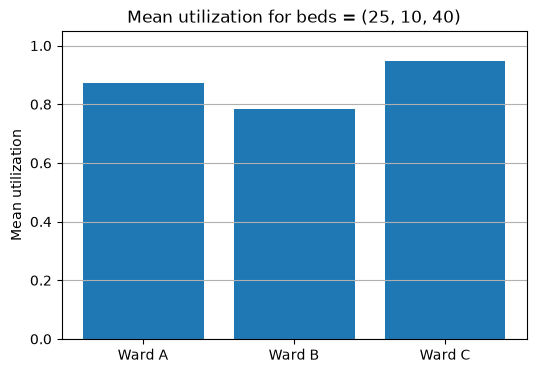

In [31]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["Ward A", "Ward B", "Ward C"],
    [
        example_rep["util_A"].mean(),
        example_rep["util_B"].mean(),
        example_rep["util_C"].mean(),
    ]
)
plt.ylim(0, 1.05)
plt.ylabel("Mean utilization")
plt.title(f"Mean utilization for beds = {example_beds}")
plt.grid(axis="y")
plt.show()

### Generate bed allocations

In [32]:
def make_allocations(total_beds, min_beds=1, step=1):
    """
    Generate allocations (bA, bB, bC) satisfying:

        bA + bB + bC = total_beds

    Each ward receives at least min_beds beds.

    step = 1 gives all integer allocations.
    step = 5 gives a coarse search.
    """
    allocations = []

    for bA in range(min_beds, total_beds - 2 * min_beds + 1, step):
        for bB in range(min_beds, total_beds - bA - min_beds + 1, step):
            bC = total_beds - bA - bB

            if bC >= min_beds:
                allocations.append((bA, bB, bC))

    return allocations

### Evaluate allocations

In [ ]:
def evaluate_allocations(allocations, n_rep=30, los_model="lognormal", seed=BASE_SEED, verbose=True):
    """
    Evaluate several bed allocations using independent replications.

    The same replication seed sequence is reused across allocations.
    This gives a common-random-numbers comparison while keeping
    replications independent within each allocation.

    The main criterion is mean total relocated patients.
    """
    rows = []

    n_alloc = len(allocations)

    for i, beds in enumerate(allocations, start=1):
        rep_df = run_replications(
            beds=beds,
            n_rep=n_rep,
            los_model=los_model,
            seed=seed
        )

        total_ci = ci_mean(rep_df["relocated_total"])

        rows.append({
            "bA": beds[0],
            "bB": beds[1],
            "bC": beds[2],
            "total_beds": sum(beds),
            "los_model": los_model,
            "n_rep": n_rep,

            "mean_relocated_total": total_ci["mean"],
            "ci_low_total": total_ci["ci_low"],
            "ci_high_total": total_ci["ci_high"],

            "mean_relocated1": rep_df["relocated1"].mean(),
            "mean_relocated2": rep_df["relocated2"].mean(),
            "mean_relocated3": rep_df["relocated3"].mean(),

            "mean_util_A": rep_df["util_A"].mean(),
            "mean_util_B": rep_df["util_B"].mean(),
            "mean_util_C": rep_df["util_C"].mean(),
        })

        if verbose and (i == 1 or i % 50 == 0 or i == n_alloc):
            print(f"Evaluated {i}/{n_alloc} allocations")

    result = pd.DataFrame(rows)
    result = result.sort_values("mean_relocated_total").reset_index(drop=True)

    return result

### Local refinement

In [34]:
def local_allocations_around(center_beds, total_beds, radius=5, min_beds=1):
    """
    Generate all allocations close to a given allocation.

    An allocation is included if each ward is within 'radius'
    beds of the center allocation.
    """
    cA, cB, cC = center_beds
    allocations = set()

    for bA in range(max(min_beds, cA - radius),
                    min(total_beds - 2 * min_beds, cA + radius) + 1):

        for bB in range(max(min_beds, cB - radius),
                        min(total_beds - bA - min_beds, cB + radius) + 1):

            bC = total_beds - bA - bB

            if bC >= min_beds and abs(bC - cC) <= radius:
                allocations.add((bA, bB, bC))

    return sorted(allocations)

In [ ]:
def simple_two_stage_search(total_beds=75,
                            los_model="lognormal",
                            coarse_step=5,
                            coarse_reps=20,
                            final_reps=100,
                            top_k=5,
                            radius=6,
                            seed=BASE_SEED):
    """
    Simple two-stage search:

    1. Coarse search with step size, e.g. 5 beds.
    2. Refined exact search near the best coarse allocations.
    """

    coarse_seed, refined_seed = spawn_child_seeds(seed, 2)

    print("Stage 1: coarse search")

    coarse_allocations = make_allocations(
        total_beds=total_beds,
        min_beds=1,
        step=coarse_step
    )

    coarse_results = evaluate_allocations(
        allocations=coarse_allocations,
        n_rep=coarse_reps,
        los_model=los_model,
        seed=coarse_seed,
        verbose=False
    )

    display(coarse_results.head(top_k))

    candidate_allocations = set()

    for _, row in coarse_results.head(top_k).iterrows():
        center = (int(row["bA"]), int(row["bB"]), int(row["bC"]))

        local = local_allocations_around(
            center_beds=center,
            total_beds=total_beds,
            radius=radius,
            min_beds=1
        )

        candidate_allocations.update(local)

    candidate_allocations = sorted(candidate_allocations)

    print(f"Stage 2: refined search over {len(candidate_allocations)} allocations")

    refined_results = evaluate_allocations(
        allocations=candidate_allocations,
        n_rep=final_reps,
        los_model=los_model,
        seed=refined_seed,
        verbose=False
    )

    return coarse_results, refined_results

### Main 75-bed search with lognormal LOS

In [ ]:
coarse_75_log, refined_75_log = simple_two_stage_search(
    total_beds=75,
    los_model="lognormal",
    coarse_step=5,
    coarse_reps=20,
    final_reps=100,
    top_k=5,
    radius=6,
    seed=BASE_SEED
)

display(refined_75_log.head(10))

Stage 1: coarse search


,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,26,1,48,75,lognormal,20,2149.80,2112.563671,2187.036329,1381.30,253.30,515.20,0.895521,0.901046,0.931703
1,31,6,38,75,lognormal,20,2153.20,2115.931178,2190.468822,1168.15,168.80,816.25,0.862970,0.843491,0.952064
2,36,6,33,75,lognormal,20,2159.65,2114.457290,2204.842710,1027.15,142.15,990.35,0.842648,0.838648,0.958034
3,36,1,38,75,lognormal,20,2165.35,2132.648418,2198.051582,1111.85,214.90,838.60,0.865428,0.888205,0.952667
4,31,1,43,75,lognormal,20,2165.75,2139.028112,2192.471888,1255.25,235.00,675.50,0.876940,0.885520,0.944082


Stage 2: refined search over 230 allocations


,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,31,1,43,75,lognormal,100,2140.11,2124.836648,2155.383352,1233.54,234.84,671.73,0.878493,0.891359,0.943921
1,35,1,39,75,lognormal,100,2143.95,2128.573069,2159.326931,1126.16,217.02,800.77,0.865329,0.895496,0.950170
2,36,2,37,75,lognormal,100,2144.23,2128.626589,2159.833411,1081.45,197.75,865.03,0.858864,0.882470,0.953773
3,29,1,45,75,lognormal,100,2144.24,2127.600515,2160.879485,1291.02,246.77,606.45,0.882473,0.894593,0.939337
4,32,1,42,75,lognormal,100,2145.18,2128.987398,2161.372602,1216.50,230.55,698.13,0.876211,0.900306,0.945487
5,25,1,49,75,lognormal,100,2145.24,2127.661283,2162.818717,1408.21,266.11,470.92,0.893115,0.898961,0.927787
6,34,1,40,75,lognormal,100,2145.56,2129.232343,2161.887657,1157.37,219.27,768.92,0.868640,0.893353,0.949243
7,31,2,42,75,lognormal,100,2145.69,2130.433796,2160.946204,1227.87,221.23,696.59,0.874098,0.885314,0.945393
8,40,2,33,75,lognormal,100,2145.90,2130.398601,2161.401399,965.15,173.33,1007.42,0.843677,0.883912,0.959233
9,29,3,43,75,lognormal,100,2146.98,2131.750061,2162.209939,1268.67,217.42,660.89,0.877651,0.873123,0.943207


In [37]:
best_75_log = refined_75_log.iloc[0]

best_beds_75_log = (
    int(best_75_log["bA"]),
    int(best_75_log["bB"]),
    int(best_75_log["bC"])
)

print("Best 75-bed allocation under lognormal LOS:")
print(best_beds_75_log)

Best 75-bed allocation under lognormal LOS:
(31, 1, 43)


The recommended allocation under the main model.

### Final estimates for the recommended 75-bed allocation

In [ ]:
final_rep_75_log = run_replications(
    beds=best_beds_75_log,
    n_rep=500,
    los_model="lognormal",
    seed=BASE_SEED
)

print("Recommended allocation:")
print(best_beds_75_log)

display(patient_performance_table(final_rep_75_log))
display(relocation_summary_table(final_rep_75_log))
display(ward_utilisation_table(final_rep_75_log, best_beds_75_log))

Recommended allocation:
(31, 1, 43)


,type,patient_group,admission_rule,mean_arrivals,mean_relocated,p_full_on_arrival,p_relocated,p_B_full_on_arrival,mean_overflow_to_A
0,1,Regular epidemic,"Ward A, otherwise relocated",2220.490,1239.014,0.557828,0.557828,NaN,NaN
1,2,Intensive epidemic,"Ward B, overflow to A, otherwise relocated",444.708,236.586,NaN,0.531682,0.937657,180.462
2,3,Other,"Ward C, otherwise relocated",2190.992,669.768,0.305398,0.305398,NaN,NaN


,group,mean_relocated,ci_low,ci_high
0,Type 1,1239.014,1234.319645,1243.708355
1,Type 2,236.586,235.077425,238.094575
2,Type 3,669.768,664.857531,674.678469
3,Total,2145.368,2138.242754,2152.493246


,ward,beds,mean_utilisation,ci_low,ci_high
0,A,31,0.877986,0.877126,0.878846
1,B,1,0.894356,0.892250,0.896463
2,C,43,0.943729,0.943281,0.944177


### Refined 75 plots

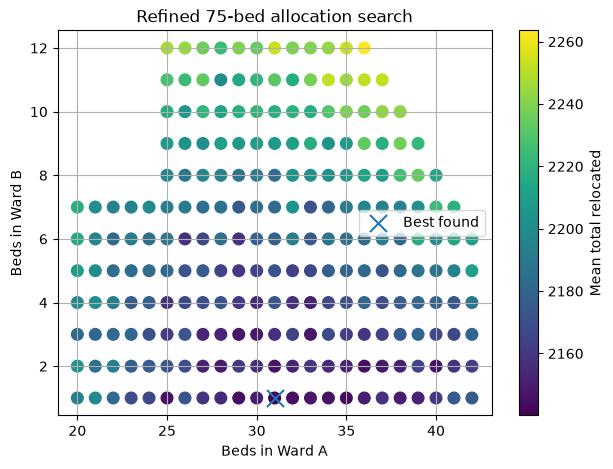

In [39]:
plt.figure(figsize=(7, 5))
plt.scatter(
    refined_75_log["bA"],
    refined_75_log["bB"],
    c=refined_75_log["mean_relocated_total"],
    s=70
)
plt.colorbar(label="Mean total relocated")

plt.scatter(
    [best_beds_75_log[0]],
    [best_beds_75_log[1]],
    marker="x",
    s=150,
    label="Best found"
)

plt.xlabel("Beds in Ward A")
plt.ylabel("Beds in Ward B")
plt.title("Refined 75-bed allocation search")
plt.legend()
plt.grid(True)
plt.show()

This plot shows the local optimization landscape. Ward C is determined by:

bC=75−bA−bB

### LOS sensitivity, exponential lOS

In [ ]:
coarse_75_exp, refined_75_exp = simple_two_stage_search(
    total_beds=75,
    los_model="exponential",
    coarse_step=5,
    coarse_reps=20,
    final_reps=100,
    top_k=5,
    radius=6,
    seed=BASE_SEED
)

display(refined_75_exp.head(10))

Stage 1: coarse search


,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,31,1,43,75,exponential,20,2140.55,2103.218784,2177.881216,1229.85,236.00,674.70,0.879040,0.898309,0.942907
1,36,1,38,75,exponential,20,2154.55,2118.376559,2190.723441,1098.50,206.05,850.00,0.861828,0.901639,0.951178
2,36,6,33,75,exponential,20,2161.05,2128.674655,2193.425345,1011.70,150.45,998.90,0.843900,0.838332,0.958498
3,41,1,33,75,exponential,20,2179.20,2146.512408,2211.887592,978.25,189.60,1011.35,0.846455,0.898556,0.957551
4,26,1,48,75,exponential,20,2182.25,2150.981994,2213.518006,1380.35,265.70,536.20,0.895814,0.893842,0.932894


Stage 2: refined search over 220 allocations


,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,31,1,43,75,exponential,100,2131.01,2116.866586,2145.153414,1228.51,234.57,667.93,0.879017,0.895450,0.942905
1,32,1,42,75,exponential,100,2139.21,2123.164445,2155.255555,1209.52,231.19,698.50,0.876215,0.890481,0.944297
2,33,1,41,75,exponential,100,2139.69,2124.557150,2154.822850,1187.67,225.10,726.92,0.872305,0.893894,0.945243
3,39,1,35,75,exponential,100,2142.37,2126.284161,2158.455839,1016.15,195.58,930.64,0.851365,0.894857,0.955452
4,28,3,44,75,exponential,100,2142.49,2126.167503,2158.812497,1294.32,221.68,626.49,0.878449,0.867760,0.939815
5,35,1,39,75,exponential,100,2142.84,2128.338664,2157.341336,1131.70,215.91,795.23,0.864897,0.899706,0.949228
6,32,3,40,75,exponential,100,2145.41,2128.742027,2162.077973,1183.33,202.64,759.44,0.867051,0.870535,0.948003
7,34,2,39,75,exponential,100,2147.47,2132.166901,2162.773099,1138.59,206.16,802.72,0.863575,0.884555,0.950131
8,32,2,41,75,exponential,100,2148.55,2131.610821,2165.489179,1204.72,218.68,725.15,0.869651,0.882535,0.945929
9,30,2,43,75,exponential,100,2149.80,2132.606622,2166.993378,1250.69,224.85,674.26,0.877095,0.884078,0.942829


In [41]:
best_75_exp = refined_75_exp.iloc[0]

best_beds_75_exp = (
    int(best_75_exp["bA"]),
    int(best_75_exp["bB"]),
    int(best_75_exp["bC"])
)

print("Best 75-bed allocation under exponential LOS:")
print(best_beds_75_exp)

Best 75-bed allocation under exponential LOS:
(31, 1, 43)


In [ ]:
final_rep_75_exp = run_replications(
    beds=best_beds_75_exp,
    n_rep=500,
    los_model="exponential",
    seed=BASE_SEED
)

display(patient_performance_table(final_rep_75_exp))
display(relocation_summary_table(final_rep_75_exp))
display(ward_utilisation_table(final_rep_75_exp, best_beds_75_exp))

,type,patient_group,admission_rule,mean_arrivals,mean_relocated,p_full_on_arrival,p_relocated,p_B_full_on_arrival,mean_overflow_to_A
0,1,Regular epidemic,"Ward A, otherwise relocated",2221.312,1239.974,0.558061,0.558061,NaN,NaN
1,2,Intensive epidemic,"Ward B, overflow to A, otherwise relocated",443.638,236.168,NaN,0.532212,0.937194,179.644
2,3,Other,"Ward C, otherwise relocated",2187.008,667.738,0.305007,0.305007,NaN,NaN


,group,mean_relocated,ci_low,ci_high
0,Type 1,1239.974,1235.349435,1244.598565
1,Type 2,236.168,234.756674,237.579326
2,Type 3,667.738,662.566808,672.909192
3,Total,2143.880,2136.396864,2151.363136


,ward,beds,mean_utilisation,ci_low,ci_high
0,A,31,0.878375,0.877503,0.879247
1,B,1,0.894783,0.892562,0.897004
2,C,43,0.942434,0.941961,0.942907


In [43]:
los_sensitivity_table = pd.DataFrame([
    {
        "LOS model": "Lognormal",
        "best_bA": best_beds_75_log[0],
        "best_bB": best_beds_75_log[1],
        "best_bC": best_beds_75_log[2],
        "mean_total_relocated": final_rep_75_log["relocated_total"].mean(),
        "mean_util_A": final_rep_75_log["util_A"].mean(),
        "mean_util_B": final_rep_75_log["util_B"].mean(),
        "mean_util_C": final_rep_75_log["util_C"].mean(),
    },
    {
        "LOS model": "Exponential",
        "best_bA": best_beds_75_exp[0],
        "best_bB": best_beds_75_exp[1],
        "best_bC": best_beds_75_exp[2],
        "mean_total_relocated": final_rep_75_exp["relocated_total"].mean(),
        "mean_util_A": final_rep_75_exp["util_A"].mean(),
        "mean_util_B": final_rep_75_exp["util_B"].mean(),
        "mean_util_C": final_rep_75_exp["util_C"].mean(),
    },
])

display(los_sensitivity_table)

,LOS model,best_bA,best_bB,best_bC,mean_total_relocated,mean_util_A,mean_util_B,mean_util_C
0,Lognormal,31,1,43,2145.368,0.877986,0.894356,0.943729
1,Exponential,31,1,43,2143.880,0.878375,0.894783,0.942434


Tests sensitivity to exponential LOS

### Sensitivity to total number of beds

In [44]:
def total_beds_sensitivity(total_beds_list,
                           los_model="lognormal",
                           coarse_step=5,
                           coarse_reps=15,
                           final_reps=75,
                           top_k=5,
                           radius=6,
                           seed=BASE_SEED):
    """
    Re-optimize the bed allocation for each total number of beds.
    """
    rows = []
    all_refined_results = {}
    search_seeds = spawn_child_seeds(seed, len(total_beds_list))

    for total_beds, search_seed in zip(total_beds_list, search_seeds):
        print("\n" + "=" * 60)
        print(f"Total beds = {total_beds}")

        coarse, refined = simple_two_stage_search(
            total_beds=total_beds,
            los_model=los_model,
            coarse_step=coarse_step,
            coarse_reps=coarse_reps,
            final_reps=final_reps,
            top_k=top_k,
            radius=radius,
            seed=search_seed
        )

        best = refined.iloc[0]

        rows.append({
            "total_beds": total_beds,
            "best_bA": int(best["bA"]),
            "best_bB": int(best["bB"]),
            "best_bC": int(best["bC"]),
            "mean_total_relocated": best["mean_relocated_total"],
            "ci_low": best["ci_low_total"],
            "ci_high": best["ci_high_total"],
            "mean_relocated1": best["mean_relocated1"],
            "mean_relocated2": best["mean_relocated2"],
            "mean_relocated3": best["mean_relocated3"],
            "mean_util_A": best["mean_util_A"],
            "mean_util_B": best["mean_util_B"],
            "mean_util_C": best["mean_util_C"],
        })

        all_refined_results[total_beds] = refined

    return pd.DataFrame(rows), all_refined_results

In [45]:
total_beds_list = [50, 60, 70, 75, 80, 90, 100]

beds_sensitivity_log, refined_by_total_beds = total_beds_sensitivity(
    total_beds_list=total_beds_list,
    los_model="lognormal",
    coarse_step=5,
    coarse_reps=15,
    final_reps=75,
    top_k=5,
    radius=6,
    seed=BASE_SEED
)

display(beds_sensitivity_log)


Total beds = 50
Stage 1: coarse search


,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,21,1,28,50,lognormal,15,2970.333333,2918.216607,3022.450060,1506.200000,286.133333,1178.000000,0.902264,0.896807,0.964576
1,31,1,18,50,lognormal,15,2987.600000,2946.961123,3028.238877,1235.666667,235.800000,1516.133333,0.875329,0.891252,0.972709
2,26,1,23,50,lognormal,15,2987.733333,2943.777555,3031.689111,1387.466667,253.466667,1346.800000,0.892184,0.891415,0.968256
3,11,1,38,50,lognormal,15,2996.866667,2969.832575,3023.900758,1836.800000,348.533333,811.533333,0.937576,0.894469,0.951772
4,36,1,13,50,lognormal,15,3011.266667,2950.960584,3071.572749,1101.600000,209.400000,1700.266667,0.861586,0.892618,0.976302


Stage 2: refined search over 239 allocations

Total beds = 60
Stage 1: coarse search


,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,26,1,33,60,lognormal,15,2632.466667,2590.253573,2674.679761,1377.066667,269.066667,986.333333,0.890581,0.904346,0.957765
1,31,1,28,60,lognormal,15,2636.933333,2604.249184,2669.617482,1221.600000,234.533333,1180.800000,0.876492,0.889318,0.965399
2,36,1,23,60,lognormal,15,2647.266667,2601.542921,2692.990412,1114.000000,211.200000,1322.066667,0.865150,0.896286,0.967356
3,21,1,38,60,lognormal,15,2659.800000,2607.230241,2712.369759,1534.466667,303.933333,821.400000,0.908168,0.897265,0.951880
4,31,6,23,60,lognormal,15,2673.466667,2623.962868,2722.970465,1177.533333,164.200000,1331.733333,0.858468,0.839317,0.968966


Stage 2: refined search over 220 allocations

Total beds = 70
Stage 1: coarse search


...

,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,41,1,48,90,lognormal,15,1663.466667,1620.859475,1706.073858,974.000000,186.066667,503.400000,0.850444,0.895628,0.931420
1,41,6,43,90,lognormal,15,1682.466667,1644.804364,1720.128969,888.000000,129.133333,665.333333,0.827661,0.837920,0.943861
2,46,1,43,90,lognormal,15,1696.533333,1661.204683,1731.861983,836.333333,160.933333,699.266667,0.835564,0.888653,0.944651
3,36,1,53,90,lognormal,15,1698.666667,1654.556075,1742.777258,1132.733333,207.466667,358.466667,0.859110,0.889837,0.916631
4,31,11,48,90,lognormal,15,1699.266667,1667.387983,1731.145350,1089.066667,104.400000,505.800000,0.849397,0.773164,0.931434


Stage 2: refined search over 275 allocations

Total beds = 100
Stage 1: coarse search


,bA,bB,bC,total_beds,los_model,n_rep,mean_relocated_total,ci_low_total,ci_high_total,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,51,1,48,100,lognormal,15,1371.266667,1307.486079,1435.047254,734.333333,141.266667,495.666667,0.817001,0.885543,0.932013
1,46,1,53,100,lognormal,15,1372.666667,1326.434475,1418.898858,849.666667,162.866667,360.133333,0.830593,0.903188,0.916280
2,46,6,48,100,lognormal,15,1390.466667,1351.483960,1429.449373,768.266667,114.000000,508.200000,0.808833,0.841155,0.931164
3,56,1,43,100,lognormal,15,1399.066667,1353.874435,1444.258899,629.066667,123.066667,646.933333,0.798334,0.908093,0.941218
4,41,6,53,100,lognormal,15,1406.933333,1364.404051,1449.462616,923.866667,135.933333,347.133333,0.826876,0.836870,0.911594


Stage 2: refined search over 230 allocations


,total_beds,best_bA,best_bB,best_bC,mean_total_relocated,ci_low,ci_high,mean_relocated1,mean_relocated2,mean_relocated3,mean_util_A,mean_util_B,mean_util_C
0,50,17,2,31,2992.026667,2977.817638,3006.235696,1633.853333,289.733333,1068.440000,0.912330,0.881105,0.961635
1,60,23,2,35,2632.013333,2613.540259,2650.486407,1457.400000,263.133333,911.480000,0.897548,0.882817,0.955979
2,70,28,1,41,2288.080000,2268.441957,2307.718043,1316.093333,248.080000,723.906667,0.886704,0.893103,0.946816
3,75,33,1,41,2115.960000,2098.253464,2133.666536,1166.133333,224.346667,725.480000,0.871176,0.896810,0.946668
4,80,32,3,45,1970.600000,1952.303637,1988.896363,1176.093333,199.120000,595.386667,0.866063,0.870960,0.938613
5,90,42,1,47,1656.680000,1637.602130,1675.757870,942.133333,179.053333,535.493333,0.844240,0.894198,0.934181
6,100,51,1,48,1365.360000,1346.370584,1384.349416,730.426667,135.906667,499.026667,0.814270,0.890410,0.931628


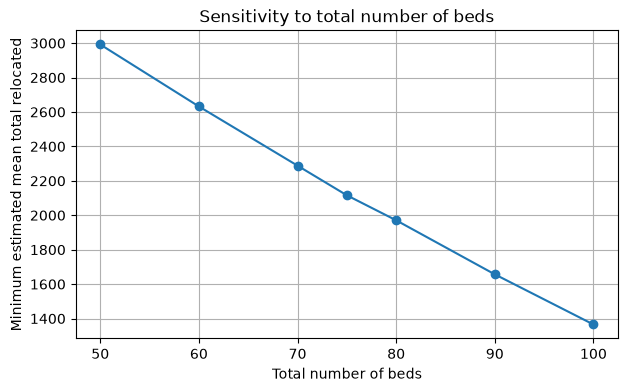

In [46]:
plt.figure(figsize=(7, 4))
plt.plot(
    beds_sensitivity_log["total_beds"],
    beds_sensitivity_log["mean_total_relocated"],
    marker="o"
)
plt.xlabel("Total number of beds")
plt.ylabel("Minimum estimated mean total relocated")
plt.title("Sensitivity to total number of beds")
plt.grid(True)
plt.show()

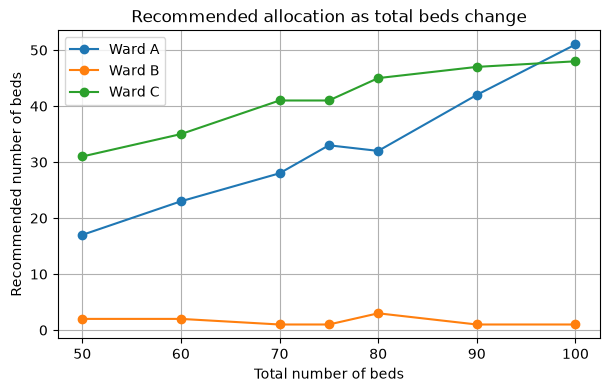

In [47]:
plt.figure(figsize=(7, 4))

plt.plot(
    beds_sensitivity_log["total_beds"],
    beds_sensitivity_log["best_bA"],
    marker="o",
    label="Ward A"
)

plt.plot(
    beds_sensitivity_log["total_beds"],
    beds_sensitivity_log["best_bB"],
    marker="o",
    label="Ward B"
)

plt.plot(
    beds_sensitivity_log["total_beds"],
    beds_sensitivity_log["best_bC"],
    marker="o",
    label="Ward C"
)

plt.xlabel("Total number of beds")
plt.ylabel("Recommended number of beds")
plt.title("Recommended allocation as total beds change")
plt.legend()
plt.grid(True)
plt.show()